#### 현재 위치 확인

In [1]:
%pwd

'd:\\Back-up\\OneDrive\\문서\\03_AIFFEL(Engineer)\\3-2_Quest test\\07_DLthon2(WALWAL)\\WALWAL\\Byung-in'

#### 클라이언트 정의

In [2]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv()


openai_api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key = openai_api_key)

#### LLM 호출

In [3]:
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(
    model = "gpt-5.4",
    temperature = 0.6,
    max_tokens = 1000
)

small_llm = ChatOpenAI(
    model = "gpt-5.4-mini",
    temperature = 0.6,
    max_tokens = 1000
)

#### 스테이트 정의

In [4]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState


class AgentState(MessagesState):
    
    # 공용
    response: str
    next: str
    reason: str
    
    # 병인님
    ## 질병 관리
    breed: str
    age: int
    weight: int
    conditions: list[str]
    symptom_raw: str
    hospital: str

    ## 의도파악
    behavior: str
    behavior_cycle: int

    # 아인님 - 서비스 관련한 질문이 들어올 때
    latest_claim: str

#### RAG 벡터 DB 구축

In [5]:
import lancedb
import json
from pathlib import Path
from langchain_openai import OpenAIEmbeddings

# 경로 설정 (base_bone.ipynb는 Byung-in/ 폴더 기준)
DATA_DIR = Path("../data_processed")
DB_PATH  = Path("../lancedb_store")

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")


def build_vector_db(force_rebuild: bool = False):
    """전처리된 JSONL을 임베딩해서 LanceDB에 저장합니다. 이미 존재하면 재사용합니다."""
    db = lancedb.connect(str(DB_PATH))

    if "walwal_rag" in db.table_names() and not force_rebuild:
        table = db.open_table("walwal_rag")
        print(f"기존 벡터 DB 로드 완료: {len(table):,}개 청크")
        return table

    # 데이터 로드
    chunks = []
    for fname in ["rag_qa_chunks.jsonl", "rag_source_chunks.jsonl"]:
        fpath = DATA_DIR / fname
        if not fpath.exists():
            print(f"[SKIP] 파일 없음: {fpath}")
            continue
        with open(fpath, encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)
                chunks.append({
                    "text":       obj["text"],
                    "source":     obj["metadata"].get("source", ""),
                    "department": obj["metadata"].get("department", ""),
                    "file_id":    obj["metadata"].get("file_id", ""),
                })
        print(f"  {fname}: {len(chunks):,}개 누적")

    print(f"\n총 {len(chunks):,}개 청크 임베딩 시작...")

    # 배치 임베딩 (500개씩)
    texts   = [c["text"] for c in chunks]
    BATCH   = 500
    vectors = []
    for i in range(0, len(texts), BATCH):
        batch = texts[i : i + BATCH]
        vectors.extend(embeddings_model.embed_documents(batch))
        print(f"  {min(i + BATCH, len(texts)):,}/{len(texts):,} 완료")

    # LanceDB 저장
    data  = [{"vector": v, **c} for v, c in zip(vectors, chunks)]
    table = db.create_table("walwal_rag", data=data, mode="overwrite")
    print(f"\n벡터 DB 구축 완료: {len(table):,}개 청크 저장됨")
    return table


rag_table = build_vector_db()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20460\864089208.py:17: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  if "walwal_rag" in db.table_names() and not force_rebuild:


  rag_qa_chunks.jsonl: 21,587개 누적
  rag_source_chunks.jsonl: 30,267개 누적

총 30,267개 청크 임베딩 시작...
  500/30,267 완료
  1,000/30,267 완료
  1,500/30,267 완료
  2,000/30,267 완료
  2,500/30,267 완료
  3,000/30,267 완료
  3,500/30,267 완료
  4,000/30,267 완료
  4,500/30,267 완료
  5,000/30,267 완료
  5,500/30,267 완료
  6,000/30,267 완료
  6,500/30,267 완료
  7,000/30,267 완료
  7,500/30,267 완료
  8,000/30,267 완료
  8,500/30,267 완료
  9,000/30,267 완료
  9,500/30,267 완료
  10,000/30,267 완료
  10,500/30,267 완료
  11,000/30,267 완료
  11,500/30,267 완료
  12,000/30,267 완료
  12,500/30,267 완료
  13,000/30,267 완료
  13,500/30,267 완료
  14,000/30,267 완료
  14,500/30,267 완료
  15,000/30,267 완료
  15,500/30,267 완료
  16,000/30,267 완료
  16,500/30,267 완료
  17,000/30,267 완료
  17,500/30,267 완료
  18,000/30,267 완료
  18,500/30,267 완료
  19,000/30,267 완료
  19,500/30,267 완료
  20,000/30,267 완료
  20,500/30,267 완료
  21,000/30,267 완료
  21,500/30,267 완료
  22,000/30,267 완료
  22,500/30,267 완료
  23,000/30,267 완료
  23,500/30,267 완료
  24,000/30,267 완료
  24,500/30,2

#### RAG 검색 함수

In [6]:
def retrieve_docs(query: str, top_k: int = 3) -> str:
    """쿼리와 관련된 문서를 LanceDB에서 검색해 포맷된 문자열로 반환합니다."""
    query_vec = embeddings_model.embed_query(query)
    results   = rag_table.search(query_vec).limit(top_k).to_list()

    if not results:
        return ""

    docs = []
    for i, r in enumerate(results, 1):
        dept = f" ({r['department']}과)" if r.get("department") else ""
        docs.append(f"[참고 자료 {i}{dept}]\n{r['text']}")

    return "\n\n".join(docs)

#### 슈퍼바이저 노드

In [7]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


class SuperVisor(BaseModel):
    
    response_reason: str
    next_node: Literal["DiseaseAgent", "Agent2", "Agent3", "Agent4", "check_doc_relevance"]

router_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            당신은 라우터 에이전트입니다.
            대화흐름을 검토하여 다음 사항을 수행하고 그 이유를 간단하게 명시하세요.
            1. 사용자가 반려동물의 질병, 증상, 건강 상태에 대해서 물으면 DiseaseAgent 노드로 연결하세요.
            2. 사용자가 반려동물의 행동에 대해서 물으면 Agent2 노드로 연결하세요.
            3. 사용자가 서비스에 대해 물으면 Agent3 노드로 연결하세요.
            4. 사용자가 그 외의 것에 대해 질문하면 check_doc_relevance 노드로 연결하세요.
            모든 결정에는 간단하고 짧게 이유를 명시하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

supervisor_llm  = small_llm.with_structured_output(SuperVisor)
router_chain = router_prompt | supervisor_llm

def supervisor(state: AgentState) -> AgentState:
    response = router_chain.invoke({"messages": state["messages"]})
    
    # 몹시 중요한 부분, 랭그래프의 상태 관리 핵심 (왜 딕셔너리 전체를 리턴하지 않는데 스테이트가 이동하는지?)
    return {
        "next": response.next_node,
        "reason": response.response_reason
    }

#### DiseaseAgent 노드

In [8]:
class DiseaseAgentOutput(BaseModel):
    
    breed:           str       = Field(description="견종, 정보 없으면 '알 수 없음'")
    age:             int       = Field(description="나이(세), 정보 없으면 -1")
    weight:          int       = Field(description="체중(kg), 정보 없으면 -1")
    conditions:      list[str] = Field(description="기저 질환 목록, 없으면 빈 리스트")
    symptom_raw:     str       = Field(description="보호자가 설명한 증상 원문 요약")
    hospital:        str       = Field(description="병원 방문 필요성: '즉시필요' | '필요' | '불필요'")
    response:        str       = Field(description="보호자에게 전달할 최종 답변")
    response_reason: str       = Field(description="이 판단에 대한 이유")


disease_agent_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            당신은 반려견 질병 관리 전문 수의사 AI입니다.
            대화를 분석하여 다음을 순서대로 수행하세요.
            1. 반려견 정보(견종, 나이, 체중, 기저질환)를 대화에서 추출하세요. 언급되지 않은 정보는 기본값으로 표시하세요.
            2. 보호자가 설명한 증상을 정확하게 요약하세요.
            3. 증상에 기반해 가능한 질환 및 원인을 전문적으로 추론하세요.
            4. 병원 방문 필요 여부를 '즉시필요' / '필요' / '불필요' 중 하나로 판단하세요.
            5. 보호자에게 전문적이고 따뜻한 어조로 최종 답변을 작성하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

disease_agent_llm   = llm.with_structured_output(DiseaseAgentOutput)
disease_agent_chain = disease_agent_prompt | disease_agent_llm


def disease_agent(state: AgentState) -> AgentState:
    # 마지막 사용자 메시지 추출
    last_msg = state["messages"][-1]
    query = last_msg.content if hasattr(last_msg, "content") else last_msg[1]

    # 관련 문서 검색
    retrieved = retrieve_docs(query, top_k=3)

    # 검색된 문서를 시스템 메시지로 주입
    messages = list(state["messages"])
    if retrieved:
        context_msg = (
            "system",
            f"다음은 관련 수의학 참고 자료입니다. 답변 시 참고하세요:\n\n{retrieved}"
        )
        messages = [context_msg] + messages

    response = disease_agent_chain.invoke({"messages": messages})

    return {
        "breed":       response.breed,
        "age":         response.age,
        "weight":      response.weight,
        "conditions":  response.conditions,
        "symptom_raw": response.symptom_raw,
        "hospital":    response.hospital,
        "response":    response.response,
        "reason":      response.response_reason,
    }

#### 포맷터 노드

In [9]:
def formatter_node(state: AgentState) -> AgentState:
    breed    = state.get("breed",    "알 수 없음")
    age      = state.get("age",      -1)
    weight   = state.get("weight",   -1)
    conds    = state.get("conditions") or []
    symptom  = state.get("symptom_raw", "")
    hospital = state.get("hospital",  "")
    answer   = state.get("response",  "")

    age_str    = f"{age}세"    if age    != -1 else "알 수 없음"
    weight_str = f"{weight}kg" if weight != -1 else "알 수 없음"
    cond_str   = ", ".join(conds) if conds else "없음"

    hospital_icon = {"즉시필요": "🚨", "필요": "⚠️", "불필요": "✅"}.get(hospital, "❓")

    formatted = f"""
🐾 반려견 정보
  견종: {breed} | 나이: {age_str} | 체중: {weight_str}
  기저질환: {cond_str}
  증상 요약: {symptom}

{hospital_icon} 병원 방문: {hospital}

💬 전문가 답변
{answer}
""".strip()

    return {"response": formatted}

#### 문서 관련도 검증 노드

In [10]:
class DocRelevanceChecker(BaseModel):
    
    response_reason: str = Field(description="결정에 대한 이유를 명시하세요")
    next_node: Literal["supervisor", "final_agent"]


relevance_checker_prompt = ChatPromptTemplate(
    [
        (
            "system", """
            1. 대화의 흐름을 참고하여, 사용자의 질문과 검색된 문서가 관련이 있는지 검사하세요.
            2. 만약 관련이 전혀 없다면, 슈퍼바이저 노드로 연결하고 그렇게 판단한 이유를 간단히 명시하세요.
            3. 검색된 문서가 없는 경우, final_agent로 보내세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

relevance_checker_llm = small_llm.with_structured_output(DocRelevanceChecker)
relevance_checker_chain = relevance_checker_prompt | relevance_checker_llm

def check_doc_relevance(state: AgentState) -> AgentState:
    response = relevance_checker_chain.invoke({"messages": state["messages"]})

    return {
        "next": response.next_node,
        "reason": response.response_reason
    }

#### 최종 답변 생성 노드

In [11]:
class FinalAnswer(BaseModel):
    
    response: str 
    response_reason: str = Field(description="답변 내용에 대한 이유를 명시하세요.")

final_answer_prompt = ChatPromptTemplate(
    [
        (
            "system", """
            1. 대화의 흐름을 참고하여, 사용자의 질문에 대한 최종 답변을 작성하세요.
            2. 답변 내용에 대한 이유를 간단히 명시하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

final_answer_llm = llm.with_structured_output(FinalAnswer)
final_answer_chain = final_answer_prompt | final_answer_llm

def final_agent(state: AgentState) -> AgentState:
    response = final_answer_chain.invoke({"messages": state["messages"]})

    return {
        "response": response.response,
        "reason": response.response_reason
    }

#### 노드를 엣지로 연결, 그래프 컴파일

In [12]:
from langgraph.graph import StateGraph, START, END


builder = StateGraph(AgentState)


builder.add_node("supervisor",         supervisor)
builder.add_node("DiseaseAgent",        disease_agent)
builder.add_node("formatter_node",      formatter_node)
builder.add_node("check_doc_relevance", check_doc_relevance)
builder.add_node("final_agent",         final_agent)


builder.add_edge(START, "supervisor")

# supervisor → 쿼리 유형에 따라 분기
builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "DiseaseAgent":        "DiseaseAgent",
        "Agent2":              "check_doc_relevance",  # 미구현 → 임시 연결
        "Agent3":              "check_doc_relevance",  # 미구현 → 임시 연결
        "Agent4":              "check_doc_relevance",  # 미구현 → 임시 연결
        "check_doc_relevance": "check_doc_relevance",
    }
)

# DiseaseAgent → formatter_node → END
builder.add_edge("DiseaseAgent",   "formatter_node")
builder.add_edge("formatter_node", END)

builder.add_conditional_edges(
    "check_doc_relevance",
    lambda state: state["next"],
    {
        "supervisor":  "supervisor",
        "final_agent": "final_agent"
    }
)

builder.add_edge("final_agent", END)


workflow = builder.compile()

#### 그래프 도식화

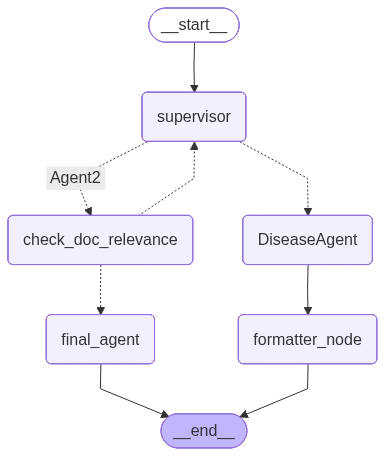

In [13]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [14]:
def run_test(message: str):
    print(f"[사용자]: {message}")
    print("-" * 60)
    inputs = {"messages": [("user", message)]}
    for output in workflow.stream(inputs):
        for key, value in output.items():
            print(f"\n[Node: {key}]")
            print(value)
    print()


# 1) 질병/건강 질문 → DiseaseAgent 라우팅 확인
run_test("우리 말티즈 5살인데 갑자기 구토를 하고 밥을 안 먹어요. 어떻게 해야 하나요?")

# 2) 기타 질문 → check_doc_relevance 라우팅 확인
run_test("왈왈 서비스 이용 방법이 궁금해요.")

[사용자]: 우리 말티즈 5살인데 갑자기 구토를 하고 밥을 안 먹어요. 어떻게 해야 하나요?
------------------------------------------------------------


d:\Back-up\OneDrive\문서\03_AIFFEL(Engineer)\3-2_Quest test\07_DLthon2(WALWAL)\WALWAL\.venv\Lib\site-packages\langsmith\client.py:538: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-9810-71c0-b502-71ef99b47fac; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-9849-78c2-a0ad-adca9e0387aa; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-9849-78c2-a0ad-add5ebe0eced; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-984a-70f2-bc66-8e8f8170e1e8; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-984b-7800-ae85-368d74a4da74



[Node: supervisor]
{'next': 'DiseaseAgent', 'reason': '구토와 식욕부진은 반려동물의 질병/건강 상태에 해당하므로 DiseaseAgent로 연결합니다.'}


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-984b-7800-ae85-368d74a4da74; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-a0ab-7bc1-9363-165d79a3b3e4; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-a0ab-7bc1-9363-165d79a3b3e4; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-9849-78c2-a0ad-add5ebe0eced; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-a0ac-7bb0-9f5d-233c8e86aa69; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-a0ac-7bb0-9f5d-233c8e86aa69; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-9849-78c2-a0ad-adca9e0387aa; trace=019d226a-9810-71c0-b502-71ef99b47fac,id=019d226a-a0ad-7811-90e1-d38c6484e7d0
Failed to send compressed multipart ingest: la


[Node: DiseaseAgent]
{'breed': '말티즈', 'age': 5, 'weight': -1, 'conditions': [], 'symptom_raw': '5살 말티즈가 갑자기 구토를 했고, 밥을 먹지 않음.', 'hospital': '필요', 'response': '말티즈 5살 아이가 갑자기 구토를 하고 식욕까지 떨어졌다면 단순 소화불량일 수도 있지만, 공복성 구토, 급성 위장염, 음식 변화, 이물 섭취, 중독, 췌장염 등 여러 원인을 확인해야 합니다. 특히 평소 잘 먹던 아이가 갑자기 밥을 거부하는 것은 가볍게 보면 안 됩니다.\n\n우선 집에서는 물은 소량씩 자주 마시게 해주시고, 간식이나 새로운 음식은 주지 말아주세요. 구토가 한두 번으로 끝나고 아이가 금방 컨디션을 회복하는 경우도 있지만, 구토가 반복되거나 물도 못 마시고 토하는 경우, 축 처짐, 복통, 설사, 피가 섞인 구토, 호흡 이상이 있으면 즉시 병원에 가셔야 합니다.\n\n현재 정보만으로는 오늘 중 병원 진료를 받아보시는 것을 권장드립니다. 어린 강아지뿐 아니라 성견에서도 이물이나 중독, 급성 내과 질환이 갑자기 나타날 수 있습니다. 가능하면 마지막으로 먹은 시간, 구토 횟수와 색, 이물 섭취 가능성, 배변 상태를 함께 정리해서 내원하시면 진료에 도움이 됩니다.', 'reason': '갑작스러운 구토와 식욕부진은 단순 위장장애부터 이물, 중독, 췌장염 등 다양한 원인이 가능하며, 식욕 저하는 임상적으로 의미 있는 이상 신호입니다. 현재 즉시 응급으로 단정할 정보는 없지만 빠른 진료가 필요한 상황입니다.'}

[Node: formatter_node]
{'response': '🐾 반려견 정보\n  견종: 말티즈 | 나이: 5세 | 체중: 알 수 없음\n  기저질환: 없음\n  증상 요약: 5살 말티즈가 갑자기 구토를 했고, 밥을 먹지 않음.\n\n⚠️ 병원 방문: 필요\n\n💬 전문가 답변\n말티즈 5살 아이가 갑자기 구토를 하고 식욕까지 떨어졌다면 단순 소화불량일 수도 있지만

...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c471-7800-8174-8941efcbb72b; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c877-7443-8e1c-f81001e63efc; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c877-7443-8e1c-f81001e63efc; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c46d-7350-910a-a8ea00e41e50; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c879-7d21-941f-271f10f9adb7; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c879-7d21-941f-271f10f9adb7; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c46c-7702-9711-98e51b2d20c5; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c87b-7cc0-b55f-767c8782c1e4; trace=019d226a-c469-7151-b1b0-5f909de9a177,id


[Node: check_doc_relevance]
{'next': 'final_agent', 'reason': '검색된 문서가 제공되지 않았으므로, 문서 관련성 판단을 할 수 없어 final_agent로 전달합니다.'}


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c881-7c21-a1d4-b573ba4001e5; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb46-75d2-bada-20f0b0ef1cbd; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb46-75d2-bada-20f0b0ef1cbd; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c87c-7601-87da-412faa24fb2f; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb4d-77d2-a353-f690f3b4904f; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb4d-77d2-a353-f690f3b4904f; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c87b-7cc0-b55f-767c8782c1e4; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb50-7440-b032-7204b3477773; trace=019d226a-c469-7151-b1b0-5f909de9a177,id


[Node: final_agent]
{'response': '왈왈 서비스 이용 방법을 안내드릴게요.\n\n1. 회원가입 및 로그인\n- 왈왈 서비스에 접속한 뒤 회원가입을 진행합니다.\n- 가입한 계정으로 로그인해주세요.\n\n2. 서비스 메뉴 확인\n- 메인 화면이나 메뉴에서 제공하는 기능을 확인합니다.\n- 필요한 서비스(예: 예약, 상담, 정보 조회 등)를 선택하세요.\n\n3. 원하는 기능 이용\n- 안내에 따라 정보를 입력하거나 요청을 진행합니다.\n- 필요한 경우 결제 또는 추가 인증 절차가 있을 수 있습니다.\n\n4. 이용 내역 확인\n- 마이페이지 또는 이용내역 메뉴에서 진행 상황과 결과를 확인할 수 있습니다.\n\n만약 왈왈이 특정 앱이나 플랫폼 이름이라면, 어떤 서비스인지 조금 더 알려주시면 더 정확하게 이용 방법을 안내해드릴 수 있어요.', 'reason': '사용자께서 ‘왈왈 서비스 이용 방법’에 대해 포괄적으로 질문하셨지만, 구체적으로 어떤 왈왈 서비스인지 정보가 없어 일반적인 서비스 이용 절차를 먼저 안내하고, 추가 정보가 있으면 더 정확히 설명드릴 수 있도록 답변했습니다.'}



Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb56-7bb0-845b-c9ea519f7c53; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-eb5e-7950-baf8-5826a23a7fd0; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-eb5e-7950-baf8-5826a23a7fd0; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb51-7af1-a955-85735b43c483; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-cb50-7440-b032-7204b3477773; trace=019d226a-c469-7151-b1b0-5f909de9a177,id=019d226a-c469-7151-b1b0-5f909de9a177
